In [42]:
import yfinance as yf
from datetime import datetime

# Define the ticker and date range
ticker = 'ZOMATO.NS'
start_date = '2024-01-01'
end_date = datetime.now().strftime('%Y-%m-%d')  # Get today's date

# Download the data
df = yf.download(ticker, start=start_date, end=end_date)
df.dropna()
# Display the data
print(df.tail(15))



[*********************100%***********************]  1 of 1 completed

Price        Adj Close       Close        High         Low        Open  \
Ticker       ZOMATO.NS   ZOMATO.NS   ZOMATO.NS   ZOMATO.NS   ZOMATO.NS   
Date                                                                     
2024-11-26  280.109985  280.109985  281.140015  272.609985  273.799988   
2024-11-27  284.720001  284.720001  289.700012  278.760010  281.000000   
2024-11-28  286.130005  286.130005  288.250000  281.429993  285.600006   
2024-11-29  279.760010  279.760010  287.489990  273.619995  285.000000   
2024-12-02  282.500000  282.500000  285.700012  280.450012  281.899994   
2024-12-03  279.850006  279.850006  282.350006  279.000000  279.700012   
2024-12-04  286.250000  286.250000  288.000000  283.000000  283.000000   
2024-12-05  299.350006  299.350006  304.649994  286.850006  288.250000   
2024-12-06  302.950012  302.950012  303.899994  296.250000  300.000000   
2024-12-09  295.299988  295.299988  304.700012  291.799988  304.700012   
2024-12-10  295.850006  295.850006  29

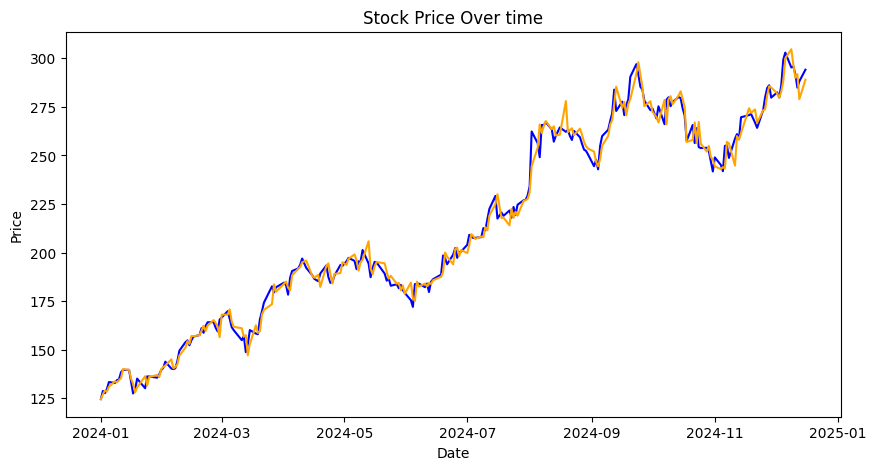

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df['Close'],label='Close Price',color='blue')
plt.plot(df['Open'],label='Open Price',color='orange')
plt.title('Stock Price Over time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

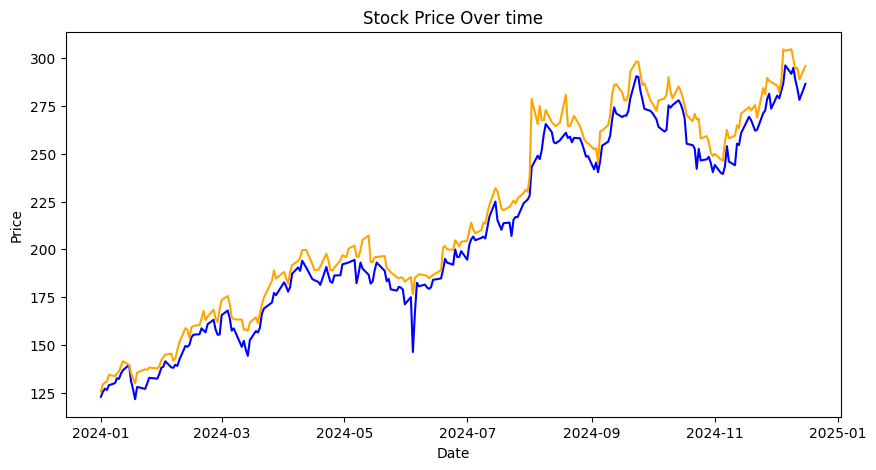

In [18]:
plt.figure(figsize=(10,5))
plt.plot(df['Low'],label='Low Price',color='blue')
plt.plot(df['High'],label='High Price',color='orange')
plt.title('Stock Price Over time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [19]:
from statsmodels.tsa.stattools import adfuller
result=adfuller(df['Close'])
print("ADF Statics : ",result[0])
print("p-value : ",result[1])
if(result[1]<=0.05):
    print("The data is stationary.")
else:
     print("The data is not stationary. Differencing might be required.")

ADF Statics :  -0.8390516329383382
p-value :  0.8073810223647948
The data is not stationary. Differencing might be required.


In [20]:

df['first_diff'] = df['Close'] - df['Close'].shift(1)

# Drop NA values and perform the ADF test
result = adfuller(df['first_diff'].dropna())

# Print the results
print("ADF Statistic:", result[0])
print("p-value:", result[1])
if result[1] <= 0.05:
    print("The data is stationary.")
else:
    print("The data is not stationary. Differencing might be required.")


ADF Statistic: -17.130104372815982
p-value: 7.15925299553057e-30
The data is stationary.


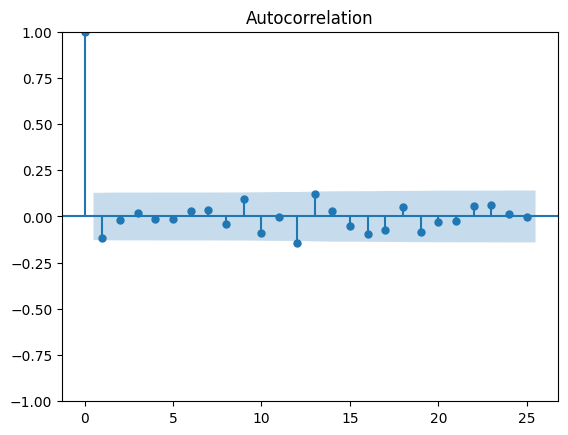

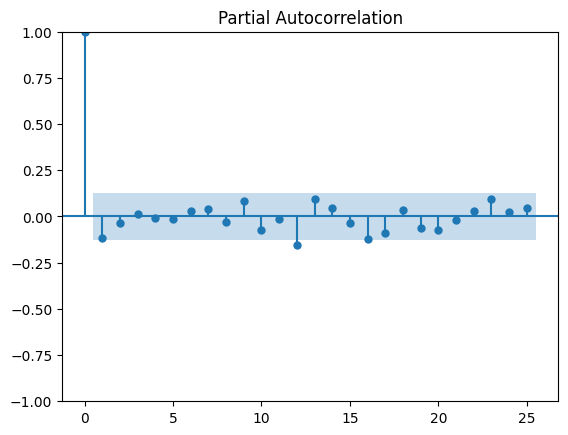

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df["first_diff"].dropna(),lags=25)
plot_pacf(df["first_diff"].dropna(),lags=25)
plt.show()

c:\Users\Shahuraje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Shahuraje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Shahuraje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Shahuraje\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Lik

Ticker       ZOMATO.NS
Date                  
2024-11-26  280.109985
2024-11-27  284.720001
2024-11-28  286.130005
2024-11-29  279.760010
2024-12-02  282.500000
2024-12-03  279.850006
2024-12-04  286.250000
2024-12-05  299.350006
2024-12-06  302.950012
2024-12-09  295.299988
2024-12-10  295.850006
2024-12-11  291.799988
2024-12-12  284.899994
2024-12-13  288.250000
2024-12-16  294.149994

 predicted data
Date
2024-11-26    271.738982
2024-11-27    278.514120
2024-11-28    287.614170
2024-11-29    282.787808
2024-12-02    278.499698
2024-12-03    281.831595
2024-12-04    283.226067
2024-12-05    289.044721
2024-12-06    296.893735
2024-12-09    301.839078
2024-12-10    296.583210
2024-12-11    293.162807
2024-12-12    291.316280
2024-12-13    288.710845
2024-12-16    293.804570
Name: predicted_mean, dtype: float64


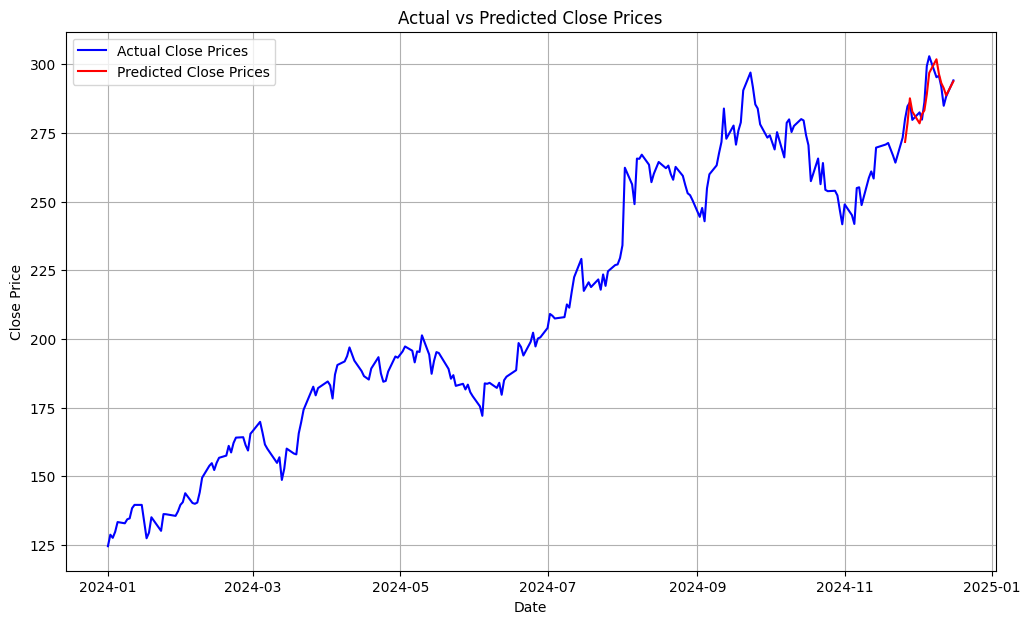

In [58]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(df['Close'], order=(12,1,12))
arima_result = model.fit()
#arima_result.summary()
start_date = pd.to_datetime("2024-11-26")  # Add time component to match data format
end_date = pd.to_datetime("2024-12-16")
if start_date not in df.index or end_date not in df.index:
    print(f"The start_date or end_date is not found in the data's index. Available dates are:")
    print(df.index.min(), "to", df.index.max())
else:
    # Predict the data for the given date range
    predicted_data = arima_result.predict(start=start_date, end=end_date, typ='levels')
    print(df['Close'].tail(15))
    print("\n predicted data")
    print(predicted_data)


# Plot the actual and predicted data
    plt.figure(figsize=(12, 7))

    # Plot the actual data
    plt.plot(df.index, df['Close'], label='Actual Close Prices', color='blue')

    # Plot the predicted data (only within the specified date range)
    plt.plot(predicted_data.index, predicted_data, label='Predicted Close Prices', color='red')

    # Title and labels
    plt.title('Actual vs Predicted Close Prices')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)

    # Show the plot
    plt.show()
